# Exploratory Data Analysis

In [1]:
import pickle
import os
import nibabel as nib
import numpy as np
import math
import torchio as tio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import matplotlib.patches as patch
from safetensors import safe_open
from glob import glob

from med_slim.utils.preprocessing.transforms import get_transforms, get_adaptive_transform

/home/qj474765/master_thesis/MedSliM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
VIEW_PLANES = ['sagittal', 'coronal', 'axial']

In [3]:
def load_nifti_image(data_root_dir, exam_id, view_plane):
    nifti_file_path = f'{data_root_dir}/{view_plane}/{exam_id}.nii.gz'
    return nib.load(nifti_file_path).get_fdata()

In [4]:
def get_num_images_per_exam(exams_path):
    num_slices_per_exam = []
    for exam in exams_path:
        with safe_open(exam, framework='pt', device='cpu') as sf:
            feats = sf.get_tensor('feats')
            num_slices_per_exam.append(feats.shape[0])   
    return np.asarray(num_slices_per_exam)

In [5]:
# Check raw slice counts from precomputed features
def plot_num_slices_per_exam(dataset_path):
    f, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True)
    for i, plane in enumerate(VIEW_PLANES):
        feat_dir = f'{dataset_path}/{plane}'
        if not os.path.exists(feat_dir):
            print(f'{plane} plane is not provided in this dataset.')
            continue
        files = glob(f'{feat_dir}/*.safetensors')
        slices = get_num_images_per_exam(files)
        print(f'{plane} (N={len(slices)}): min={min(slices)}, max={max(slices)}, mean={np.mean(slices):.1f}, median={np.median(slices):.0f}, std={np.std(slices):.1f}')
        sns.histplot(slices, ax=axes[i], kde=True)
        axes[i].set_title(f'{plane} plane')

In [6]:
def get_inplane_resolution(data_root_dir, view_plane, n=500):
    files = glob(f"{data_root_dir}/{view_plane}/*.nii.gz")
    samples = random.sample(files, n)
    if files:
        shapes = []
        spacings = []
        for f in samples:
            img = nib.load(f)
            shapes.append(img.shape)
            spacings.append(img.header.get_zooms())
        shapes = np.array(shapes)
        spacings = np.array(spacings)
        avg_inplane = np.mean(shapes, axis=0)
        avg_inplane = np.rint(avg_inplane).astype(int)
        avg_spacing = np.round(np.mean(spacings, axis=0), 3)
        print(f'{view_plane}: Avg in-plane resolution {avg_inplane}')
        print(f'{view_plane}: Avg spacing {avg_spacing}')
    else:
        raise FileNotFoundError

## MRNet

### Check in-plane resolution distribution

In [7]:
get_inplane_resolution('/hpcwork/rwth1833/datasets/preprocessed/MRNet/train', VIEW_PLANES[0], n=100)

sagittal: Avg in-plane resolution [256 256  31]
sagittal: Avg spacing [1. 1. 1.]


In [8]:
get_inplane_resolution('/hpcwork/rwth1833/datasets/preprocessed/MRNet/train', VIEW_PLANES[1], n=100)

coronal: Avg in-plane resolution [256 256  29]
coronal: Avg spacing [1. 1. 1.]


In [9]:
get_inplane_resolution('/hpcwork/rwth1833/datasets/preprocessed/MRNet/train', VIEW_PLANES[2], n=100)

axial: Avg in-plane resolution [256 256  35]
axial: Avg spacing [1. 1. 1.]


### Before `torchio.transforms`

In [10]:
data_root_dir = '/hpcwork/rwth1833/datasets/preprocessed/MRNet/train'
exam_id = '1129'

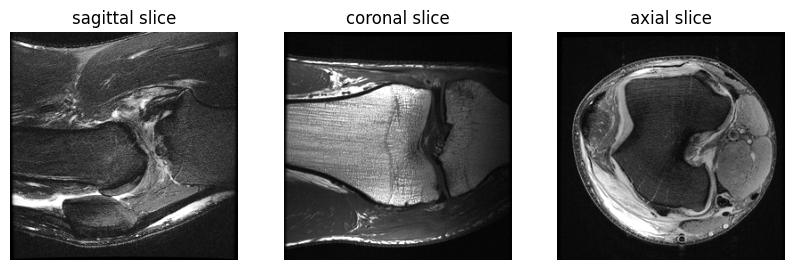

In [11]:
# Access center slices along different axes (e.g., axial, sagittal, coronal)
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
for i, slice_view in enumerate(VIEW_PLANES):
    image = load_nifti_image(data_root_dir, exam_id, slice_view)
    slice_idx = image.shape[-1] // 2
    axes[i].imshow(image[:, :, slice_idx], cmap='gray', origin='lower')
    axes[i].set_title(f'{slice_view} slice')
    axes[i].axis('off')
plt.show()

In [12]:
# Load an image
image = load_nifti_image(data_root_dir, exam_id, VIEW_PLANES[0])
image.shape

(256, 256, 34)

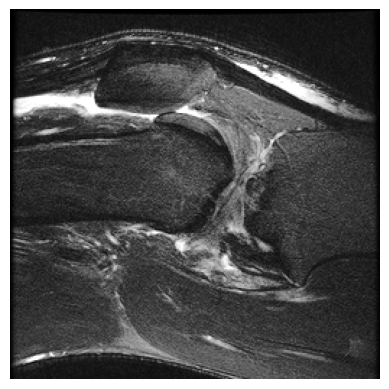

In [13]:
slice_idx = image.shape[-1] // 2
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.axis('off')
plt.show()

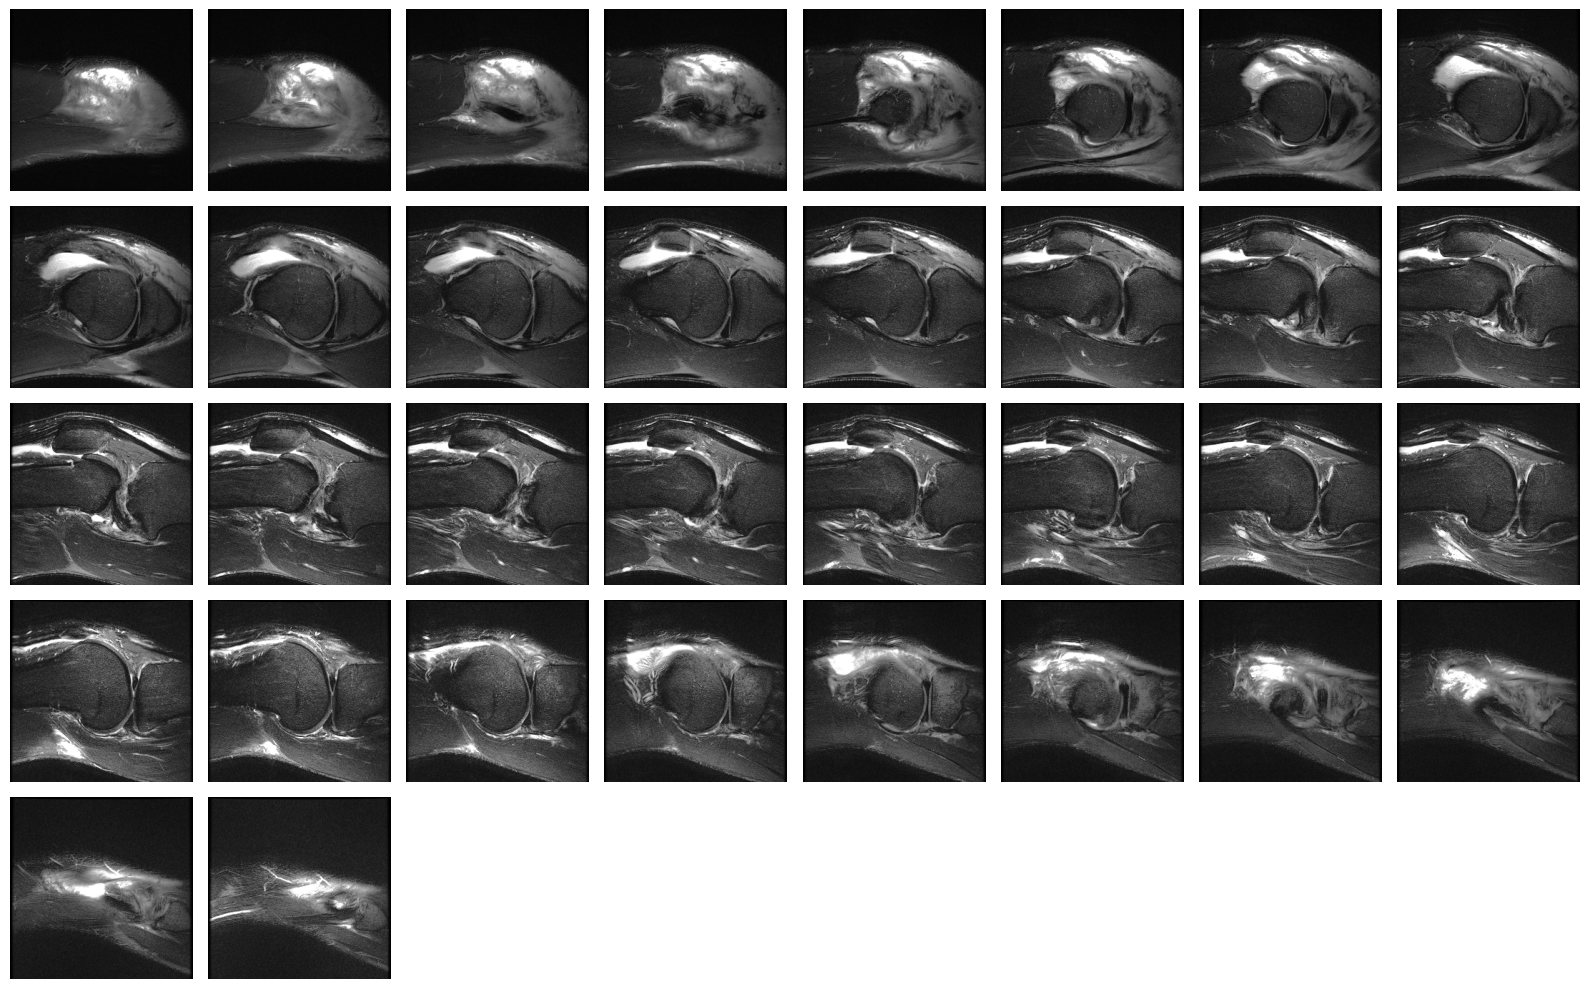

In [14]:
num_slices = image.shape[-1]
n_cols = 8
n_rows = math.ceil(num_slices / n_cols)

plt.figure(figsize=(n_cols * 2, n_rows * 2))
for i in range(num_slices):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(image[:, :,i], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

### After `torchio.transforms`

#### Resize transform

In [19]:
_, val_tf = get_transforms(model_name="dinov2", spatial_mode="resize", to_tensor=True)

In [20]:
nifti_file_path = f'{data_root_dir}/{VIEW_PLANES[0]}/{exam_id}.nii.gz'
original_image = tio.ScalarImage(nifti_file_path)
print(f"Original image shape: {original_image.shape}")
print(f"Original image spacing: {original_image.spacing}")

Original image shape: (1, 256, 256, 34)
Original image spacing: (1.0, 1.0, 1.0)


In [21]:
transformed_image = val_tf(original_image)
print(f"Transformed image shape: {transformed_image.shape}")

Transformed image shape: torch.Size([1, 34, 224, 224])


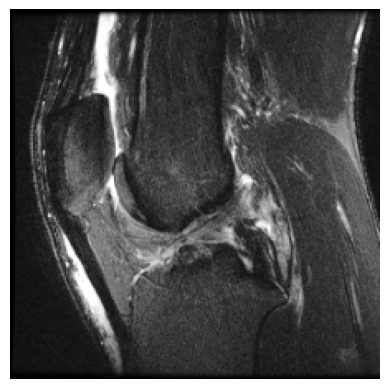

In [22]:
transformed_image = transformed_image.numpy().squeeze(axis=0) # Remove channel dimension for visualization 
slice_idx = transformed_image.shape[0] // 2
plt.imshow(transformed_image[slice_idx], cmap='gray')
plt.axis('off')
plt.show()

#### Adaptive transform based on dataset in-plane resolution and pretrained FM required resolution: 
In this case, CropOrPad

In [ ]:
adaptive_tf = get_adaptive_transform(model_name="dinov2")
nifti_file_path = f'{data_root_dir}/{VIEW_PLANES[0]}/{exam_id}.nii.gz'
original_image = tio.ScalarImage(nifti_file_path)
print(f"Original image shape: {original_image.shape}")
print(f"Original image spacing: {original_image.spacing}")

In [ ]:
transformed_image = adaptive_tf(original_image)
print(f"Transformed image shape: {transformed_image.shape}")
transformed_image = transformed_image.numpy().squeeze(axis=0) # Remove channel dimension for visualization 
slice_idx = transformed_image.shape[0] // 2
plt.imshow(transformed_image[slice_idx], cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
num_slices = transformed_image.shape[0]
n_cols = 8
n_rows = math.ceil(num_slices / n_cols)

plt.figure(figsize=(n_cols * 2, n_rows * 2))
for i in range(num_slices):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(transformed_image[i], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

### Slice Count distribution

sagittal (N=1130): min=17, max=51, mean=30.4, median=30, std=7.0
coronal (N=1130): min=17, max=58, mean=29.8, median=30, std=8.7
axial (N=1130): min=19, max=61, mean=34.3, median=35, std=7.5


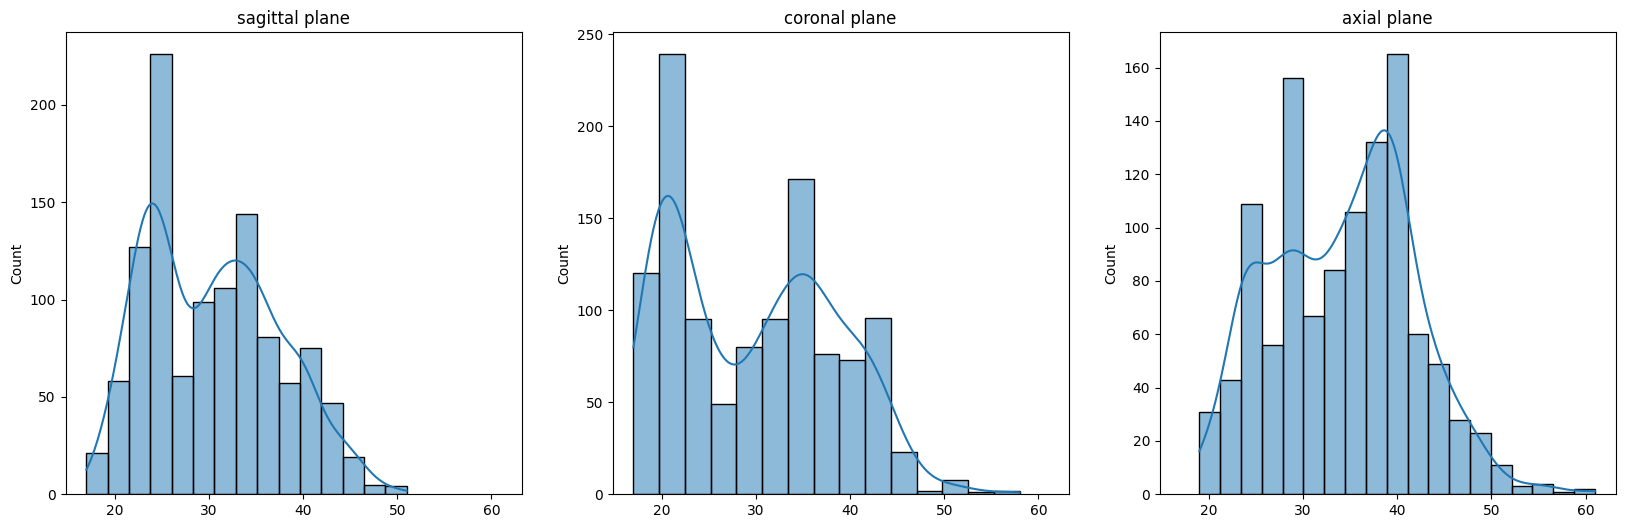

In [30]:
feat_dir = '/hpcwork/rwth1833/feat_caches/MRNet/slices_raw/crop/dinov2/train/'
plot_num_slices_per_exam(feat_dir)

sagittal (N=120): min=21, max=45, mean=30.5, median=30, std=6.3
coronal (N=120): min=17, max=48, mean=29.4, median=30, std=8.4
axial (N=120): min=20, max=52, mean=34.3, median=34, std=7.1


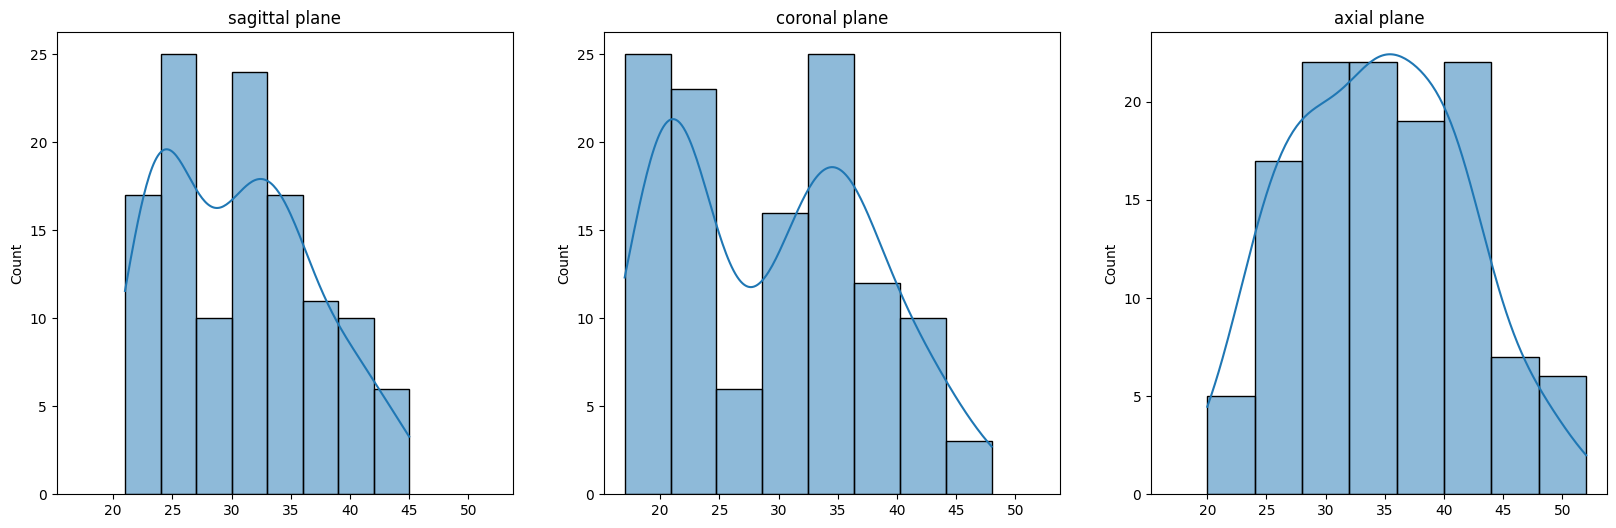

In [31]:
feat_dir = '/hpcwork/rwth1833/feat_caches/MRNet/slices_raw/crop/dinov2/test/'
plot_num_slices_per_exam(feat_dir)

## kneeMRI

#### Raw data

In [ ]:
# directory where the volumetric data is located
volumetric_data_dir = '/hpcwork/rwth1833/datasets/kneeMRI/vol_train'

# path to metadata csv file
metadata_csv_path = '/hpcwork/rwth1833/datasets/kneeMRI/metadata.csv'

# names=True loads the interprets the first row of csv file as column names
# 'i4' = 4 byte signed integer, 'U20' = unicode max 20 char string
metadata = np.genfromtxt(metadata_csv_path, delimiter=',', names=True, 
    dtype='i4,i4,i4,i4,i4,i4,i4,i4,i4,i4,U20') 

print('Column names:')
print(metadata.dtype.names)

# Select the specified examID
exams = metadata[metadata['examId'] == 518793]


In [ ]:
for exam in exams:
    vol_data_file = exam['volumeFilename']

    vol_data_path = os.path.join(volumetric_data_dir, vol_data_file)

    # Load data from file
    with open(vol_data_path, 'rb') as file_handler: # Must use 'rb' as the data is binary
        volumetric_data = pickle.load(file_handler)
    
    print('\nShape of volume "%s":' % vol_data_path, volumetric_data.shape)
    
    # Get all roi slices from volume
    z_start = exam['roiZ']
    depth = exam['roiDepth']
    
    for z in range(z_start, z_start + depth):
    
        slice = volumetric_data[z, :, :]
        
        # Get roi dimensions
        x, y, w, h = [exam[attr] for attr in ['roiX', 'roiY', 'roiWidth', 'roiHeight']]
        
        # Extract ROI
        roi = slice[y:y+h, x:x+w]
        
        # Plot slice and roi
        figure = plt.figure()
        plot = plt.subplot2grid((1, 4), (0, 0), 1, 3) # This makes the slice plot larger than roi plot
        plot.add_patch(patch.Rectangle((x, y), w, h, fill=None, color='red'))
        plot.imshow(slice, cmap='gray')
        plot = plt.subplot2grid((1, 4), (0, 3), 1, 1)
        plot.imshow(roi, cmap='gray')
        
        plt.show()

In [ ]:
data_root_dir = '/hpcwork/rwth1833/datasets/preprocessed/kneeMRI/train'
image = load_nifti_image(data_root_dir,"518793-5", VIEW_PLANES[0])
image.shape

In [ ]:
slice_idx = image.shape[-1] // 2
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.axis('off')
plt.show()

#### Check in-plane resolution

In [32]:
get_inplane_resolution('/hpcwork/rwth1833/datasets/preprocessed/kneeMRI/train', VIEW_PLANES[0], n=100)

sagittal: Avg in-plane resolution [320 320  31]
sagittal: Avg spacing [1. 1. 1.]


#### After `torchio.transform`

In [ ]:
exam_id = "518793-5"
_, val_tf = get_transforms(model_name="dinov2", spatial_mode="crop", to_tensor=True)
nifti_file_path = f'{data_root_dir}/{VIEW_PLANES[0]}/{exam_id}.nii.gz'
original_image = tio.ScalarImage(nifti_file_path)
print(f"Original image shape: {original_image.shape}")
print(f"Original image spacing: {original_image.spacing}")
transformed_image = val_tf(original_image)
print(f"Transformed image shape: {transformed_image.shape}")

In [ ]:
transformed_image = transformed_image.numpy().squeeze(axis=0) # Remove channel dimension for visualization 
slice_idx = transformed_image.shape[0] // 2
plt.imshow(transformed_image[slice_idx], cmap='gray')
plt.axis('off')
plt.show()

#### Slice counts distribution

sagittal (N=644): min=22, max=45, mean=30.9, median=30, std=2.1
coronal plane is not provided in this dataset.
axial plane is not provided in this dataset.


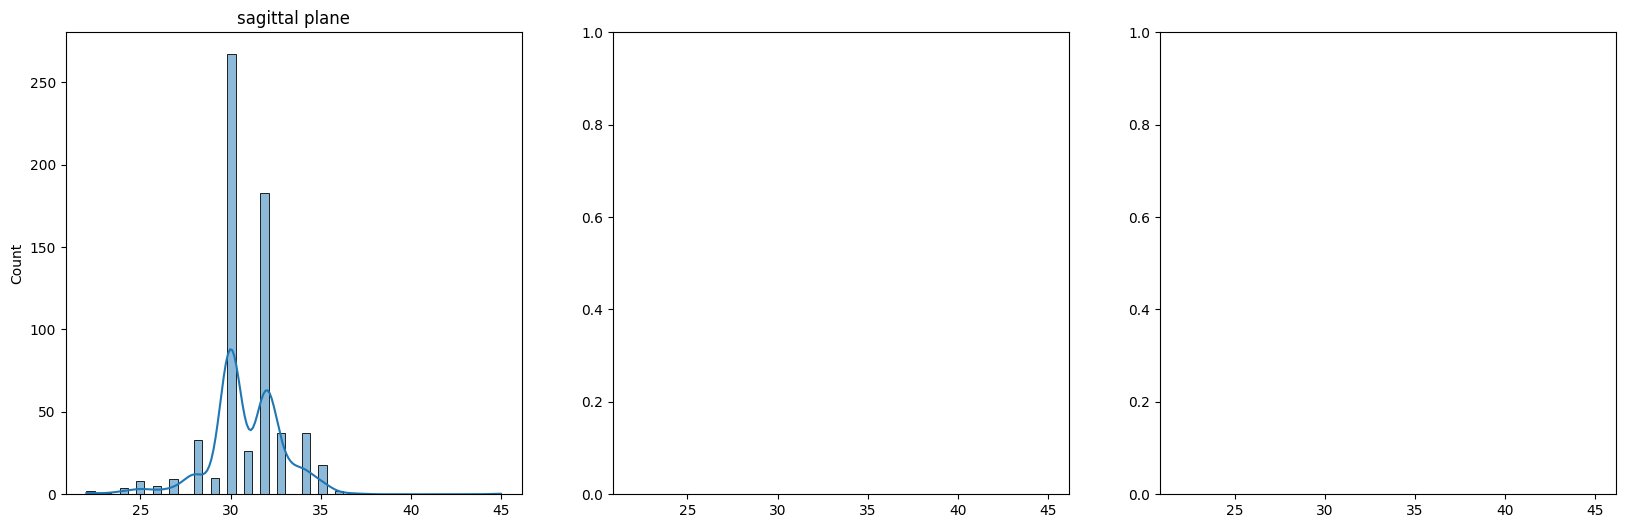

In [33]:
feat_dir = '/hpcwork/rwth1833/feat_caches/kneeMRI/slices_raw/crop/dinov2/train/'
plot_num_slices_per_exam(feat_dir)

## fastMRI

### In-plane resolution distribution

In [9]:
for view_plane in VIEW_PLANES:
    get_inplane_resolution('/hpcwork/rwth1833/datasets/preprocessed/fastMRI/train', view_plane, n=100)

sagittal: Avg in-plane resolution [394 394  33]
sagittal: Avg spacing [0.387 0.387 3.403]
coronal: Avg in-plane resolution [390 392  31]
coronal: Avg spacing [0.398 0.398 3.646]
axial: Avg in-plane resolution [325 326  35]
axial: Avg spacing [0.481 0.481 3.694]


### Before `torchio.transforms`

In [ ]:
data_root_dir = '/work/rwth1833/datasets/preprocessed/fastMRI/train'
view_plane = VIEW_PLANES[0]
exam_id = 'study_42f9ce23_MR7_0d20a763'
image = load_nifti_image(data_root_dir, exam_id, view_plane)
image.shape

In [ ]:
slice_idx = image.shape[-1] // 2
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.axis('off')
plt.show()

### After `torchio.transforms`

In [ ]:
adaptive_tf = get_adaptive_transform(model_name="ark")
nifti_file_path = f'{data_root_dir}/{VIEW_PLANES[0]}/{exam_id}.nii.gz'
original_image = tio.ScalarImage(nifti_file_path)
print(f"Original image shape: {original_image.shape}")
print(f"Original image spacing: {original_image.spacing}")
transformed_image = adaptive_tf(original_image)
print(f"Transformed image shape: {transformed_image.shape}")
transformed_image = transformed_image.numpy().squeeze(axis=0) # Remove channel dimension for visualization 
slice_idx = transformed_image.shape[0] // 2
plt.imshow(transformed_image[slice_idx], cmap='gray')
plt.axis('off')
plt.show()

### Before `torchio.transforms`

In [ ]:
data_root_dir = '/work/rwth1833/datasets/preprocessed/fastMRI/train/'
view_plane = VIEW_PLANES[2]
exam_id = 'study_39a470be_MR4_21d1f671'
image = load_nifti_image(data_root_dir, exam_id, view_plane)
image.shape

In [ ]:
slice_idx = image.shape[-1] // 2
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.axis('off')
plt.show()

### After `torchio.transforms`

In [ ]:
adaptive_tf = get_adaptive_transform(model_name="rad-dino")
nifti_file_path = f'{data_root_dir}/{VIEW_PLANES[2]}/{exam_id}.nii.gz'
original_image = tio.ScalarImage(nifti_file_path)
print(f"Original image shape: {original_image.shape}")
print(f"Original image spacing: {original_image.spacing}")
transformed_image = adaptive_tf(original_image)
print(f"Transformed image shape: {transformed_image.shape}")
transformed_image = transformed_image.numpy().squeeze(axis=0) # Remove channel dimension for visualization 
slice_idx = transformed_image.shape[0] // 2
plt.imshow(transformed_image[slice_idx], cmap='gray')
plt.axis('off')
plt.show()

### Before `torchio.transforms`

In [ ]:
data_root_dir = '/work/rwth1833/datasets/preprocessed/fastMRI/train/'
view_plane = VIEW_PLANES[1]
exam_id = 'study_16dabf31_MR10_93ddb94c'
image = load_nifti_image(data_root_dir, exam_id, view_plane)
image.shape

In [ ]:
slice_idx = image.shape[-1] // 2
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.axis('off')
plt.show()

### After `torchio.transforms`

In [ ]:
_, val_tf = get_transforms(model_name="dinov3", spatial_mode="resample", to_tensor=True)
original_image = tio.ScalarImage(f'{data_root_dir}/{view_plane}/{exam_id}.nii.gz')
print(f"Original image shape: {original_image.shape}")
print(f"Original image spacing: {original_image.spacing}")
transformed_image = val_tf(original_image)
print(f"Transformed image shape: {transformed_image.shape}")

In [ ]:
transformed_image = transformed_image.numpy().squeeze(axis=0) # Remove channel dimension for visualization 
plt.imshow(transformed_image[slice_idx], cmap='gray')
plt.axis('off')
plt.show()

### Slcie counts distribution

sagittal (N=9940): min=14, max=56, mean=32.2, median=32, std=4.0
coronal (N=11935): min=12, max=75, mean=31.8, median=32, std=4.9
axial (N=5743): min=11, max=90, mean=34.2, median=34, std=5.0


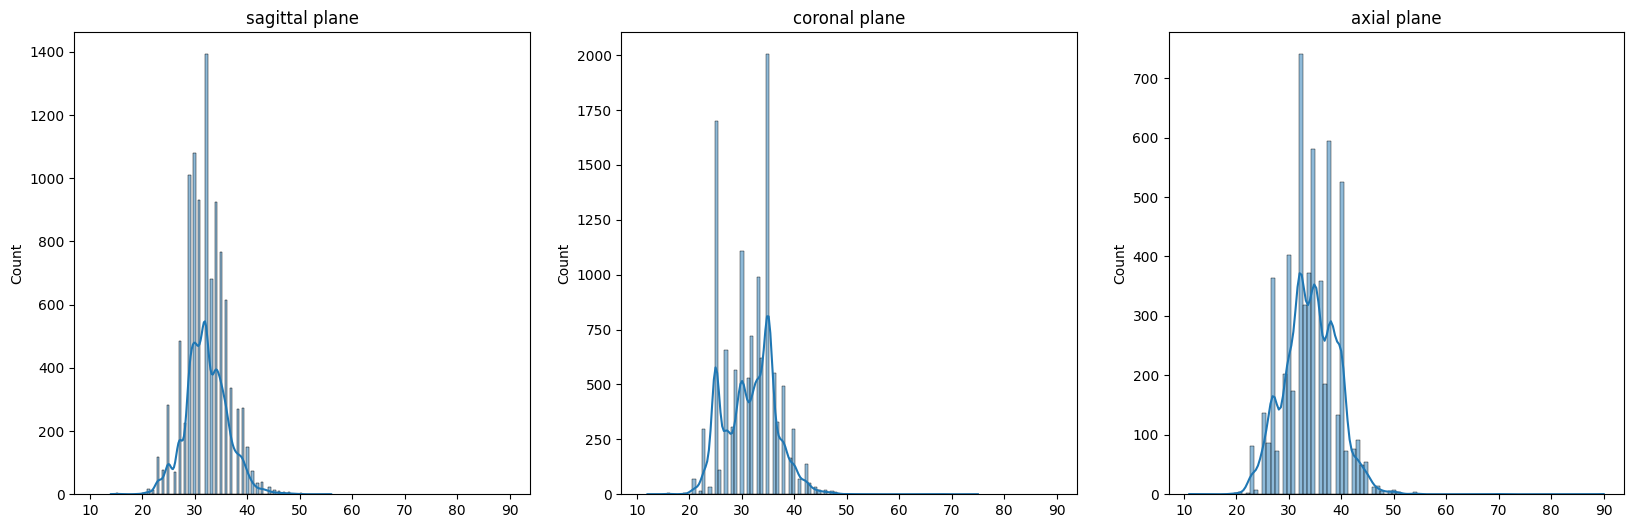

In [10]:
feat_dir = '/hpcwork/rwth1833/feat_caches/fastMRI/slices_raw/adaptive/dinov2/train/'
plot_num_slices_per_exam(feat_dir)

## KMAR-50K

In [11]:
for view_plane in VIEW_PLANES:
    get_inplane_resolution('/hpcwork/rwth1833/datasets/preprocessed/KMAR-50K/train', view_plane, n=100)

sagittal: Avg in-plane resolution [487 486  23]
sagittal: Avg spacing [0.386 0.386 4.191]
coronal: Avg in-plane resolution [444 479  23]
coronal: Avg spacing [0.394 0.394 4.099]
axial: Avg in-plane resolution [366 386  25]
axial: Avg spacing [0.52  0.52  4.574]


### Before `torchio.transforms`

In [ ]:
nifti_file_path = '/hpcwork/rwth1833/datasets/preprocessed/KMAR-50K/train/sagittal/2021_20210630003548_0.0.nii.gz'
image = nib.load(nifti_file_path).get_fdata()
image.shape

In [ ]:
slice_idx = image.shape[-1] // 2
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.axis('off')
plt.show()

### After `torchio.transforms`

In [ ]:
adaptive_tf = get_adaptive_transform(model_name="biomedclip")

In [ ]:
original_image = tio.ScalarImage(nifti_file_path)
print(f"Original image shape: {original_image.shape}")
print(f"Original image spacing: {original_image.spacing}")
transformed_image = adaptive_tf(original_image)
print(f"Transformed image shape: {transformed_image.shape}")

In [ ]:
transformed_image = transformed_image.numpy().squeeze(axis=0) # Remove channel dimension for visualization 
plt.imshow(transformed_image[slice_idx], cmap='gray')
plt.axis('off')
plt.show()

### Slice counts distribution

sagittal (N=511): min=19, max=32, mean=22.3, median=22, std=1.5
coronal (N=440): min=12, max=32, mean=22.5, median=22, std=1.7
axial (N=492): min=20, max=40, mean=24.8, median=25, std=3.5


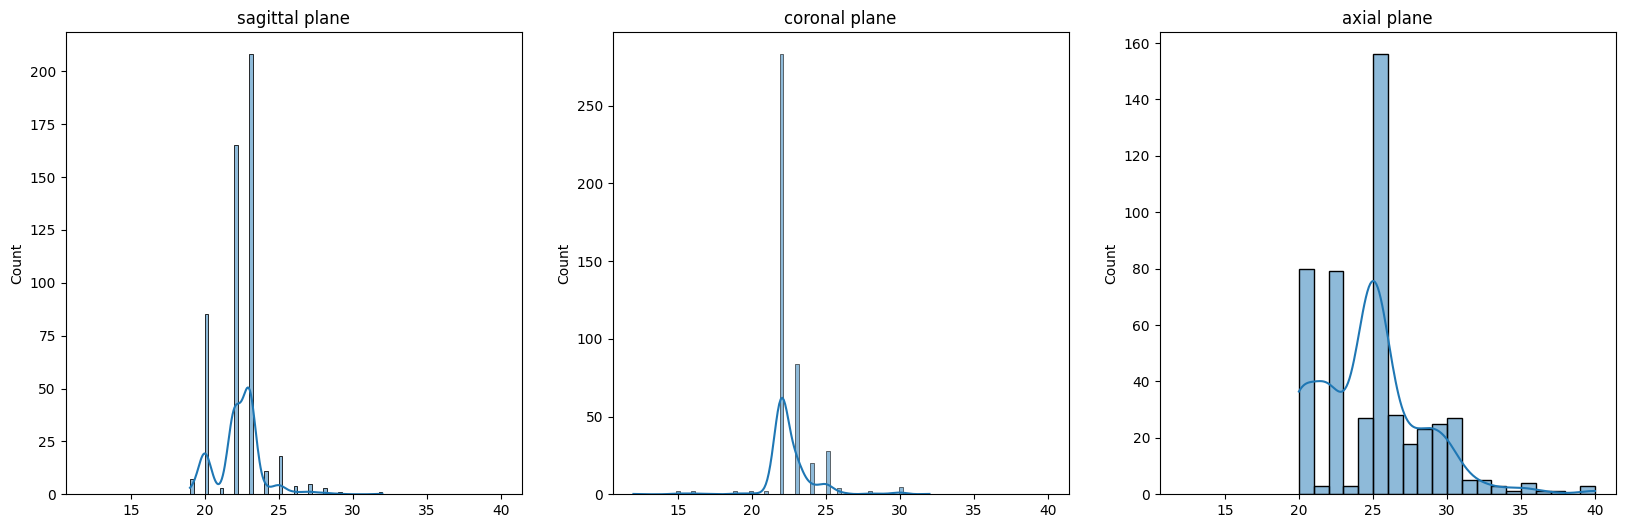

In [12]:
feat_dir = '/hpcwork/rwth1833/feat_caches/KMAR-50K/slices_raw/adaptive/dinov2/train/'
plot_num_slices_per_exam(feat_dir)

## SKM-TEA

### Before `torchio.transforms`

In [ ]:
nifti_file_path = '/hpcwork/rwth1833/datasets/preprocessed/SKM-TEA/train/sagittal/DESS_E1/MTR_093.nii.gz'
image = nib.load(nifti_file_path).get_fdata()
image.shape

In [ ]:
slice_idx = image.shape[-1] // 2
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.axis('off')
plt.show()

### After `torchio.transforms`

In [ ]:
adaptive_tf = get_adaptive_transform(model_name="ark")
original_image = tio.ScalarImage(nifti_file_path)
print(f"Original image shape: {original_image.shape}")
print(f"Original image spacing: {original_image.spacing}")
transformed_image = adaptive_tf(original_image)
print(f"Transformed image shape: {transformed_image.shape}")

In [ ]:
transformed_image = transformed_image.numpy().squeeze(axis=0) # Remove channel dimension for visualization 
plt.imshow(transformed_image[slice_idx], cmap='gray')
plt.axis('off')
plt.show()